# Methanol synthesis loop: PFR surrogate pipeline

One run, top to bottom, from a fresh kernel:

- **A** explore the HYSYS loop over the T-P design box (heatmaps);
- **B** record the reactor inlet the loop produces and turn it into the surrogate's training box;
- **C** sample the isolated PFR over that box and train two surrogates, `stoi` (reaction extents, mass balance by construction) and `raw` (outlet flows directly);
- **D** validate the loop with the PFR replaced by each surrogate against the HYSYS loop, point by point;
- **E** nested-sampling feasibility analysis on the surrogate loop, benchmarked against the same analysis on HYSYS.

HYSYS plumbing lives in `hysys.py`, `hysys_methanol.py`, `hysys_pfr.py`, `hysys_surrogate.py`; sampling and the MLP in `helpers.py`.

In [36]:
# Imports
import time
import itertools
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nested_sampler as ns          # https://github.com/Kai360-dot/NestedSampler

from hysys import open_case
from helpers import generate_sobol_points, fit_mlp, cross_validate, select_width
import hysys_loop as loop        # full loop, PFR solved by HYSYS       (methanol_loop.hsc)
import hysys_pfr as pfr              # isolated reactor                     (methanol_pfr.hsc)
import hysys_surrogate as sur        # loop with the PFR replaced by a net  (methanol_surrogate_no_rcy.hsc)

In [37]:
# KNOBS
SMOKE_TEST = False                          # few points to check the machinery; False for the real run
TAG = "_smoke" if SMOKE_TEST else ""       # suffix of every file this notebook writes

CASES = Path("C:/Users/kr326/Documents/HYSYS_MeOH/AspenFiles")
CASE_LOOP = str(CASES / "methanol_loop.hsc")            # original flowsheet
CASE_PFR = str(CASES / "methanol_pfr.hsc")              # reactor with its inlet and outlet streams only
CASE_SUR = str(CASES / "methanol_surrogate_no_rcy.hsc")        # copy of the loop with Reactor100 ignored

# design variables; key order defines x = (T, P) everywhere below
design_bounds = {"temperature_C": [220, 280], "pressure_bar": [70, 120]}
RATIO, PURGE_RATE, VOLUME = 3.0, 0.03, 35          # fixed: H2:CO2 feed ratio, purge fraction, reactor m3
SEGMENTS = 10 if SMOKE_TEST else 50
INFLATE = 0.15                                     # widening of the reactor-inlet hull, both sides
NET = "raw"                                        # surrogate in the feasibility analysis: "raw" or "stoi"

# constraints, feasible iff residual <= 0 (see constraints below)
MEOH_MIN = 18_000                  # kg/h methanol product
COMPRESSION_MAX = 4_000            # kW, syngas + recycle compressors
CO_MAX = 6                         # kgmole/h net CO formed in the reactor

# stage sizes
N_GRID = 9 if SMOKE_TEST else 30                            # A: points per axis of the T-P grid
N_DOMAIN = 8 if SMOKE_TEST else 32                          # B: Sobol points of the loop for the inlet hull
N_PFR = 256 if SMOKE_TEST else 1024                          # C: Sobol points of the reactor (power of two)
N_LIVE, N_PROP = (40, 10) if SMOKE_TEST else (1000, 250)    # E: nested sampler
MAX_TIME = 0                                                # E: s wall time per sampler run

In [38]:
# Setup: attach to the three cases (HYSYS is launched for any that is not open)
t0 = time.time()
case_loop, case_pfr, case_sur = (open_case(c) for c in (CASE_LOOP, CASE_PFR, CASE_SUR))
objects_loop = loop.cache_objects(case_loop, segments=SEGMENTS)
objects_pfr = pfr.cache_objects(case_pfr, segments=SEGMENTS)   # objects_sur needs the box from Part B
print(f"three cases attached in {time.time() - t0:.0f} s")

three cases attached in 1 s


In [39]:
# Loop adapters: design vector -> result row, the constraints on a row, and a sweep helper
def row_hysys(x):
    T, P = x
    return loop.run_point(objects_loop, pressure=(P, "bar"), temperature=(T, "C"),
                          volume=(VOLUME, "m3"), ratio=RATIO, purge_rate=PURGE_RATE)

def constraints(row, relax: float):
    """Residuals, feasible iff every value <= 0."""
    if not row["converged"]:
        raise RuntimeError("not converged")          # sampler drops the point, counts a failure
    return [MEOH_MIN * (1 - relax) - row["methanol_kg_h"],
            row["compression_kW"] - COMPRESSION_MAX * (1 + relax),
            row["co_formation_kgmole_h"] - CO_MAX * (1 + relax)]

def loop_rows(points, model):
    """One row per design point; a point that raises is kept as not converged."""
    points = list(points)
    rows, t0 = [], time.time()
    num_pts = len(points)
    every = max(num_pts // 10, 1)
    for i, x in enumerate(points, start=1):
        try:
            rows.append({**model(x), **dict(zip(design_bounds, x))})    # set values win: exact grid keys
        except Exception as e:
            rows.append({**dict(zip(design_bounds, x)), "converged": False, "error": str(e)})
        if (i % every == 0 or i == num_pts):
            el = time.time() - t0
            print(f"{i}/{num_pts} {el/60:.1f} min elapsed")
    return pd.DataFrame(rows)

## Part A: loop exploration

In [40]:
# T-P grid of the loop at fixed ratio, purge and volume
T_axis = np.linspace(*design_bounds["temperature_C"], N_GRID)
P_axis = np.linspace(*design_bounds["pressure_bar"], N_GRID)
t0 = time.time()
df_sweep = loop_rows(itertools.product(T_axis, P_axis), row_hysys)
print(f"{len(df_sweep)} points, {int(df_sweep.converged.sum())} converged, {time.time() - t0:.0f} s")

90/900 5.5 min elapsed
180/900 11.1 min elapsed
270/900 16.7 min elapsed
360/900 22.6 min elapsed
450/900 28.2 min elapsed
540/900 33.4 min elapsed
630/900 37.9 min elapsed
720/900 41.3 min elapsed
810/900 45.5 min elapsed
900/900 49.9 min elapsed
900 points, 900 converged, 2994 s


In [41]:
def heatmap(df, value, label, *,
            x="temperature_C", y="pressure_bar",
            levels=16, cmap="viridis", ax=None, title=None):
    """Heatmap of value over (x, y); non-converged cells are left blank."""
    if not df["converged"].all():
        print("Warning: Not all points converged")

    _df = df.copy()
    _df["value_plot"] = _df[value].where(_df["converged"])
    grid = _df.pivot(index=y, columns=x, values="value_plot")
    if ax is None:
        _, ax = plt.subplots(1, 1)
    mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap=cmap, shading="nearest")
    cs = ax.contour(grid.columns, grid.index, grid.values, levels=levels, colors="black", linewidths=1)
    ax.clabel(cs, fmt="%g")
    ax.set_xlabel("T [°C]")
    ax.set_ylabel("Pressure [bar]")
    ax.set_title(title)
    ax.figure.colorbar(mesh, ax=ax, label=label)
    return ax

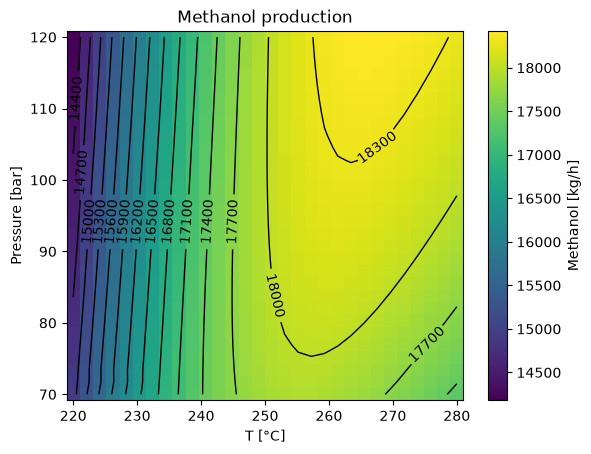

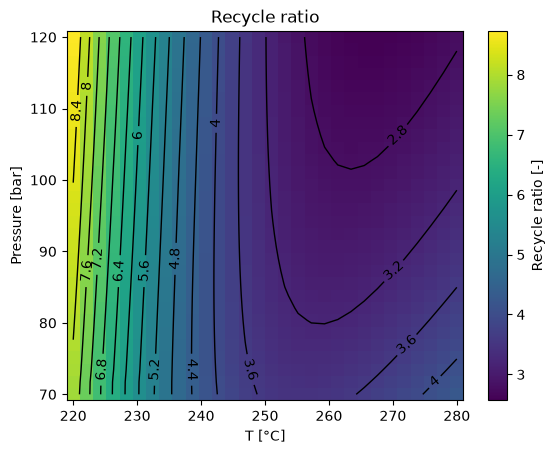

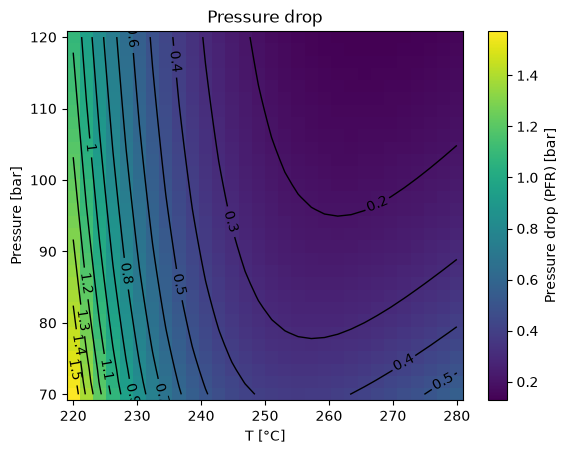

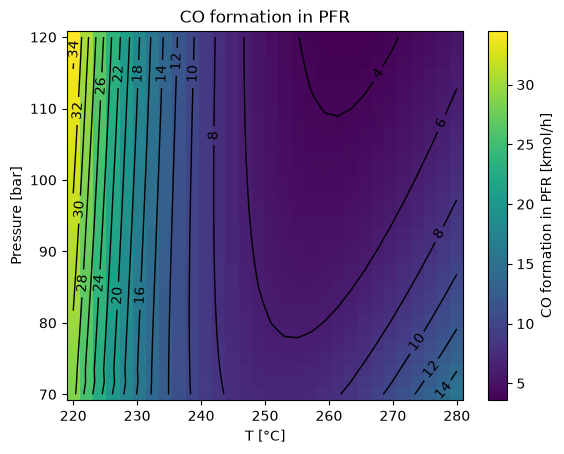

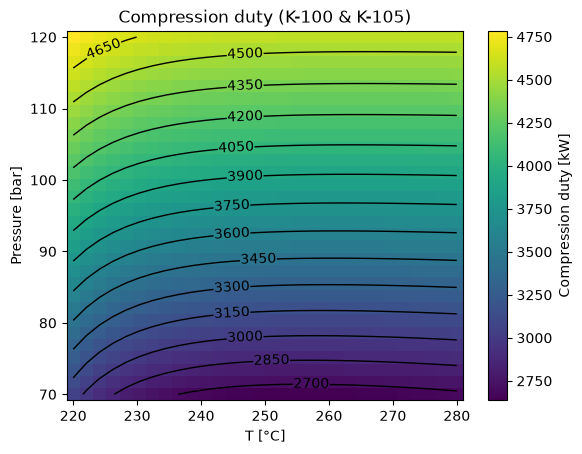

In [42]:
heatmap(df_sweep, "methanol_kg_h", "Methanol [kg/h]", title="Methanol production", levels=15)
heatmap(df_sweep, "recycle_ratio", "Recycle ratio [-]", title="Recycle ratio")
heatmap(df_sweep, "reactor_dP_bar", "Pressure drop (PFR) [bar]", title="Pressure drop")
heatmap(df_sweep, "co_formation_kgmole_h", "CO formation in PFR [kmol/h]", title="CO formation in PFR")
heatmap(df_sweep, "compression_kW", "Compression duty [kW]", title="Compression duty (K-100 & K-105)");

## Part B: reactor-inlet domain, the surrogate's training box

In [43]:
# Sobol sample of the loop over the design box; run_point records the reactor inlet at each point
bounds = np.array(list(zip(*design_bounds.values())))          # 2 x d: lower row, upper row
t0 = time.time()
df_dom = loop_rows(generate_sobol_points(N_DOMAIN, bounds), row_hysys)
print(f"{len(df_dom)} points, {int(df_dom.converged.sum())} converged, {time.time() - t0:.0f} s")

3/32 0.5 min elapsed
6/32 0.9 min elapsed
9/32 1.3 min elapsed
12/32 1.8 min elapsed
15/32 2.3 min elapsed
18/32 2.8 min elapsed
21/32 3.2 min elapsed
24/32 3.6 min elapsed
27/32 4.0 min elapsed
30/32 4.6 min elapsed
32/32 4.8 min elapsed
32 points, 32 converged, 287 s


In [44]:
# Hull of the reactor inlet over the converged points, inflated -> training box in sur.INPUTS order
# NOTE: Units (Flows): kgmole/s
dom_ok = df_dom[df_dom["converged"]].reset_index(drop=True)
hull = {c: (dom_ok[f"in_{c}_kgmole_h"].min() / 3600, dom_ok[f"in_{c}_kgmole_h"].max() / 3600)   # kgmole/s
        for c in sur.COMPONENTS}
pfr_box = {**design_bounds, **{c: [lo * (1 - INFLATE), hi * (1 + INFLATE)] for c, (lo, hi) in hull.items()}}
assert list(pfr_box) == sur.INPUTS
pd.DataFrame(pfr_box, index=["lower", "upper"]).T

,lower,upper
temperature_C,220.000000,280.000000
pressure_bar,70.000000,120.000000
Hydrogen,1.775204,5.638583
CO,0.028333,0.301439
CO2,0.339388,1.353624
H2O,0.006702,0.011494
Methanol,0.002850,0.013983
Nitrogen,0.047808,0.068054


## Part C: PFR sampling and surrogate training

In [45]:
# Reactor sampling: vector in pfr_box order -> one HYSYS solve of the isolated PFR
def pfr_row(x):
    p = dict(zip(pfr_box, x))
    return pfr.run_point(objects_pfr, temperature=(p["temperature_C"], "C"), pressure=(p["pressure_bar"], "bar"),
                         volume=(VOLUME, "m3"), flows=({c: p[c] for c in sur.COMPONENTS}, "kgmole/s"))

def unit_sobol_sample(bounds, model, n_pts):
    lb = np.array([b[0] for b in bounds.values()])
    ub = np.array([b[1] for b in bounds.values()])
    input_var = generate_sobol_points(n=n_pts, bounds=np.stack((lb, ub)))
    results = []
    for iv in input_var:
        res = {**dict(zip(bounds, iv)), **model(iv)}
        results.append(res)
    return pd.DataFrame(results)

t0 = time.time()
df_pfr = unit_sobol_sample(pfr_box, pfr_row, N_PFR)
print(f"{len(df_pfr)} evaluations, {int(df_pfr.converged.sum())} converged, {time.time() - t0:.0f} s")
df_pfr.to_csv(f"pfr_sobol{TAG}.csv", index=False)

1024 evaluations, 1024 converged, 117 s


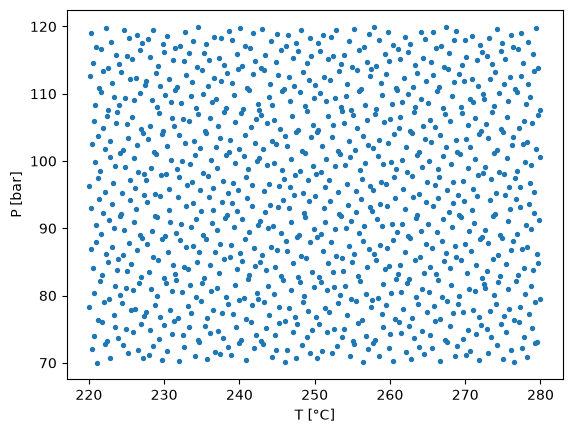

In [46]:
# Sampled design points in the T-P plane; the six flow dimensions are projected out
fig, ax = plt.subplots()
ax.scatter(df_pfr.temperature_C, df_pfr.pressure_bar, s=8)
ax.set(xlabel="T [°C]", ylabel="P [bar]");

In [47]:
# Two surrogates of the same reactor, trained on the same inputs:
#   stoi: predicts the extents of the two independent reactions
#           xi1: CO2 + 3 H2 -> CH3OH + H2O      xi2: CO2 + H2 -> CO + H2O
#         plus duty and pressure drop; outlet = inlet + sur.STOICH @ extents, so the
#         atom balances hold by construction (sur.stoi_as_raw does that reconstruction).
#   raw:  predicts the six outlet flows plus duty and pressure drop directly.
# NOTE: key "Hydrogen" yields kgmole/s (analogous for other 5 components)
pfr_ok = df_pfr[df_pfr["converged"]].reset_index(drop=True)
X = pfr_ok[list(pfr_box)].to_numpy()                      # inputs in box order
Y_stoi = pd.DataFrame({
    "xi_meoh_kgmole_h": pfr_ok.out_Methanol_kgmole_h - pfr_ok.in_Methanol_kgmole_h,
    "xi_co_kgmole_h":   pfr_ok.out_CO_kgmole_h - pfr_ok.in_CO_kgmole_h,
    "reactor_duty_kW":  pfr_ok.reactor_duty_kW,
    "reactor_dP_bar":   pfr_ok.reactor_dP_bar,
})
Y_raw = pd.concat([pfr_ok[[f"out_{c}_kgmole_h" for c in sur.COMPONENTS]],
                   pfr_ok[["reactor_duty_kW", "reactor_dP_bar"]]], axis=1)
print(f"{len(X)} training points, {X.shape[1]} inputs -> stoi {Y_stoi.shape[1]} outputs, raw {Y_raw.shape[1]} outputs")

1024 training points, 8 inputs -> stoi 4 outputs, raw 8 outputs


In [48]:
def train_surrogate(X, Y: pd.DataFrame, name: str):
    """Width search, 5-fold CV report, final fit on all data, export.  Returns (model, rmse, Y_oof)."""
    t0 = time.time()
    width, table = select_width(X, Y.to_numpy(), verbose=False)
    rmse, Y_oof = cross_validate(X, Y.to_numpy(), hidden=width)
    model = fit_mlp(X, Y.to_numpy(), hidden=width)
    model.export(f"pfr_surrogate_{name}{TAG}.txt")
    print(f"=== {name}: width {width} ({time.time() - t0:.0f} s)   CV rmse/std per width: "
          + ", ".join(f"{w}: {v:.4f}" for w, v in table.items()))
    for col, r, span in zip(Y.columns, rmse, Y.max() - Y.min()):
        print(f"  {col:22s} {r:9.3f}   {100 * r / span:5.2f} % of range")
    return model, rmse, Y_oof

stoi, rmse_stoi, oof_stoi = train_surrogate(X, Y_stoi, "stoi")
raw, rmse_raw, oof_raw = train_surrogate(X, Y_raw, "raw")
nets = {"stoi": sur.stoi_as_raw(stoi), "raw": raw}       # both with the raw interface: outlet flows, duty, dP

=== stoi: width 64 (48 s)   CV rmse/std per width: 4: 0.1064, 8: 0.0434, 16: 0.0174, 32: 0.0122, 64: 0.0109, 128: 0.0136
  xi_meoh_kgmole_h           3.573    0.24 % of range
  xi_co_kgmole_h             3.137    0.26 % of range
  reactor_duty_kW           78.858    0.23 % of range
  reactor_dP_bar             0.002    0.14 % of range
=== raw: width 64 (49 s)   CV rmse/std per width: 4: 0.3681, 8: 0.0986, 16: 0.0362, 32: 0.0183, 64: 0.0112, 128: 0.0112
  out_Hydrogen_kgmole_h     26.273    0.18 % of range
  out_CO_kgmole_h            2.948    0.33 % of range
  out_CO2_kgmole_h           7.852    0.20 % of range
  out_H2O_kgmole_h           3.510    0.24 % of range
  out_Methanol_kgmole_h      3.648    0.24 % of range
  out_Nitrogen_kgmole_h      0.157    0.22 % of range
  reactor_duty_kW           83.034    0.25 % of range
  reactor_dP_bar             0.003    0.19 % of range


out-of-fold RMSE of outlet flows [kgmole/h]:
             range  stoi_rmse  raw_rmse
Hydrogen  14657.37      10.22     26.27
CO          887.40       3.14      2.95
CO2        3917.14       3.98      7.85
H2O        1433.85       3.98      3.51
Methanol   1524.24       3.57      3.65
Nitrogen     72.83       0.00      0.16

raw net atom balance error, out minus in [kgmole/h]  (stoi: zero by construction):
  C: rms    7.23   max   43.48
  O: rms   14.30   max   80.34
  H: rms   50.64   max  252.71


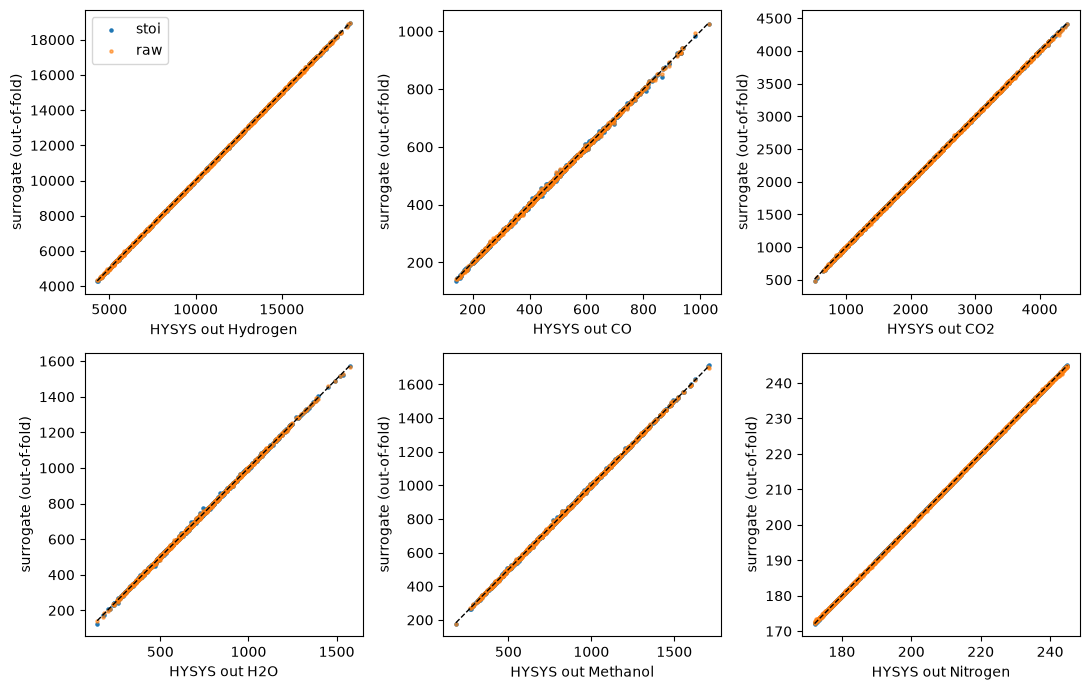

In [49]:
# Side by side on the same footing: outlet flows, with the stoi outlets rebuilt from its
# out-of-fold extents, and the atom balances of the raw net's outlets
inlet = pfr_ok[[f"in_{c}_kgmole_h" for c in sur.COMPONENTS]].to_numpy()
outlet = pfr_ok[[f"out_{c}_kgmole_h" for c in sur.COMPONENTS]].to_numpy()
out_stoi = inlet + oof_stoi[:, :2] @ sur.STOICH.T
comparison = pd.DataFrame({
    "range": outlet.max(0) - outlet.min(0),
    "stoi_rmse": np.sqrt(((out_stoi - outlet) ** 2).mean(0)),
    "raw_rmse": np.sqrt(((oof_raw[:, :6] - outlet) ** 2).mean(0)),
}, index=sur.COMPONENTS).round(2)
print("out-of-fold RMSE of outlet flows [kgmole/h]:")
print(comparison)

ATOMS = {"C": [0, 1, 1, 0, 1, 0], "O": [0, 1, 2, 1, 1, 0], "H": [2, 0, 0, 2, 4, 0]}   # per sur.COMPONENTS
print()
print("raw net atom balance error, out minus in [kgmole/h]  (stoi: zero by construction):")
for atom, v in ATOMS.items():
    err = (oof_raw[:, :6] - inlet) @ np.array(v, float)
    print(f"  {atom}: rms {np.sqrt((err ** 2).mean()):7.2f}   max {np.abs(err).max():7.2f}")

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, c, y, a, b in zip(axes.flat, sur.COMPONENTS, outlet.T, out_stoi.T, oof_raw[:, :6].T):
    ax.scatter(y, a, s=5, label="stoi")
    ax.scatter(y, b, s=5, label="raw", alpha=0.6)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=1)
    ax.set(xlabel=f"HYSYS out {c}", ylabel="surrogate (out-of-fold)")
axes.flat[0].legend()
fig.tight_layout()

In [50]:
# Sanity check on one point: both surrogates against HYSYS
row = pfr_ok.iloc[0]
x = row[list(pfr_box)].to_numpy(dtype=float)
pred = {name: net(x)[:6] for name, net in nets.items()}
for i, c in enumerate(sur.COMPONENTS):
    print(f"  {c:9s} HYSYS {row[f'out_{c}_kgmole_h']:9.2f}   stoi {pred['stoi'][i]:9.2f}   raw {pred['raw'][i]:9.2f} kgmole/h")

  Hydrogen  HYSYS  15421.37   stoi  15416.44   raw  15418.71 kgmole/h
  CO        HYSYS    311.48   stoi    310.20   raw    309.35 kgmole/h
  CO2       HYSYS   1476.76   stoi   1475.88   raw   1476.15 kgmole/h
  H2O       HYSYS    871.59   stoi    872.38   raw    873.13 kgmole/h
  Methanol  HYSYS    714.38   stoi    716.35   raw    717.02 kgmole/h
  Nitrogen  HYSYS    216.13   stoi    216.13   raw    216.28 kgmole/h


## Part D: the loop with the surrogate in place of the PFR

In [51]:
# The cut flowsheet: RoutV is written from the net each tear pass, the rest is solved by HYSYS
objects_sur = sur.cache_objects(case_sur, pfr_box)

def row_surrogate(x, net):
    T, P = x
    return sur.run_point(objects_sur, net, pressure=(P, "bar"), temperature=(T, "C"),
                         ratio=RATIO, purge_rate=PURGE_RATE)

In [52]:
# Point-wise validation against the HYSYS rows of Part B, both nets
KEYS = ["methanol_kg_h", "compression_kW", "co_formation_kgmole_h", "recycle_ratio"]
for name, net in nets.items():
    t0 = time.time()
    pred = loop_rows(dom_ok[list(design_bounds)].to_numpy(), partial(row_surrogate, net=net))
    conv = pred["converged"].to_numpy()
    print(f"=== {name}: {int(conv.sum())}/{len(pred)} converged, mean {pred.tear_passes.mean():.0f} tear passes, "
          f"{int(pred.outside_box.dropna().map(len).gt(0).sum())} points outside the box, {time.time() - t0:.0f} s")
    for k in KEYS:
        err = (pred[k] - dom_ok[k])[conv]
        rmse = np.sqrt((err ** 2).mean())
        print(f"  {k:22s} rmse {rmse:9.3f}   max |err| {err.abs().max():9.3f}   "
              f"({100 * rmse / dom_ok[k].abs().mean():.2f} % of mean)")

3/32 0.0 min elapsed
6/32 0.1 min elapsed
9/32 0.2 min elapsed
12/32 0.3 min elapsed
15/32 0.4 min elapsed
18/32 0.4 min elapsed
21/32 0.5 min elapsed
24/32 0.6 min elapsed
27/32 0.6 min elapsed
30/32 0.7 min elapsed
32/32 0.7 min elapsed
=== stoi: 32/32 converged, mean 23 tear passes, 0 points outside the box, 44 s
  methanol_kg_h          rmse    44.880   max |err|   122.851   (0.26 % of mean)
  compression_kW         rmse     2.301   max |err|    12.007   (0.06 % of mean)
  co_formation_kgmole_h  rmse     0.270   max |err|     0.831   (2.64 % of mean)
  recycle_ratio          rmse     0.035   max |err|     0.092   (0.83 % of mean)
3/32 0.1 min elapsed
6/32 0.2 min elapsed
9/32 0.2 min elapsed
12/32 0.3 min elapsed
15/32 0.4 min elapsed
18/32 0.5 min elapsed
21/32 0.5 min elapsed
24/32 0.6 min elapsed
27/32 0.7 min elapsed
30/32 0.8 min elapsed
32/32 0.9 min elapsed
=== raw: 32/32 converged, mean 28 tear passes, 0 points outside the box, 51 s
  methanol_kg_h          rmse   167.544  

## Part E: feasibility analysis, surrogate loop against the HYSYS benchmark

In [53]:
def nested_sample_flowsheet(box, model, constraints, *, n_live, n_prop, max_time=0):
    """Nested-sample the region where constraints(model(x)) <= 0 over `box`
    ({name: [lb, ub]}, order defines x).  Returns the sampler Result and a
    DataFrame with one row per evaluation, failed ones included."""
    rows = []

    def g(x):
        row = {**dict(zip(box, x)), **model(x)}
        rows.append(row)                          # kept even if the constraints raise
        residuals = constraints(row)
        row["max_residual"] = max(residuals)      # <= 0 means feasible
        return residuals

    lb, ub = zip(*box.values())
    result = ns.NestedSampler(g, lb, ub, num_live=n_live, num_prop=n_prop, max_time=max_time).sample()
    return result, pd.DataFrame(rows)

In [54]:
runs = {}
for name, model in (("surrogate", partial(row_surrogate, net=nets[NET])), ("hysys", row_hysys)):
    t0 = time.time()
    result, df = nested_sample_flowsheet(design_bounds, model, partial(constraints, relax = 0.05 if name=="surrogate" else 0),
                                         n_live=N_LIVE, n_prop=N_PROP, max_time=MAX_TIME)
    df["feasible"] = df["max_residual"] <= 0
    runs[name] = dict(result=result, df=df, wall_s=time.time() - t0)
    print(f"=== {name}: {len(df)} evaluations, {int(df.feasible.sum())} feasible, "
          f"{result.stats.failures} failed, status {result.status.name}, {runs[name]['wall_s']:.0f} s")


** INITIALIZING LIVE POINTS (1000)   1396.42 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     3.0970e+03   260        0     3.0000e-01
     10    -6.9992e-02  1029     1346     2.2924e-01
=== surrogate: 3500 evaluations, 1030 feasible, 0 failed, status NORMAL, 3236 s

** INITIALIZING LIVE POINTS (1000)  13542.52 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     3.7664e+03   140        0     3.0000e-01
     16    -3.4823e-02  1009     1951     2.0312e-01
=== hysys: 5000 evaluations, 1009 feasible, 0 failed, status NORMAL, 81551 s


In [55]:
# Verification: every point the surrogate called feasible is re-evaluated on HYSYS
sur_df, hys_df = runs["surrogate"]["df"], runs["hysys"]["df"]
cand = sur_df[sur_df.feasible].copy()
t0 = time.time()
checks = [row_hysys((r.temperature_C, r.pressure_bar)) for r in cand.itertuples()]
cand["hysys_max_residual"] = [max(constraints(c, relax=0)) if c["converged"] else np.nan for c in checks]
cand["verified"] = cand.hysys_max_residual <= 0
print(f"{len(cand)} surrogate-feasible points re-run on HYSYS in {time.time() - t0:.0f} s: "
      f"{int(cand.verified.sum())} confirmed, {int((~cand.verified).sum())} rejected")
print(cand[["temperature_C", "pressure_bar", "max_residual", "hysys_max_residual", "verified"]].round(2).to_string(index=False))

1030 surrogate-feasible points re-run on HYSYS in 5318 s: 545 confirmed, 485 rejected
 temperature_C  pressure_bar  max_residual  hysys_max_residual  verified
        250.00         95.00         -1.05               26.09     False
        246.25         98.12         -0.20              225.56     False
        268.75        104.38         -1.58               31.18     False
        253.75         91.88         -1.23               -0.92      True
        263.12         87.19         -0.59               -0.34      True
        259.38        102.81         -2.00               -1.71      True
        266.88        109.06         -1.84              197.09     False
        252.81        108.28         -1.72              174.18     False
        275.31        102.03         -0.40                0.16     False
        260.31         89.53         -1.07               -0.83      True
        264.06         98.91         -1.66               -1.29      True
        256.56         80.16         -

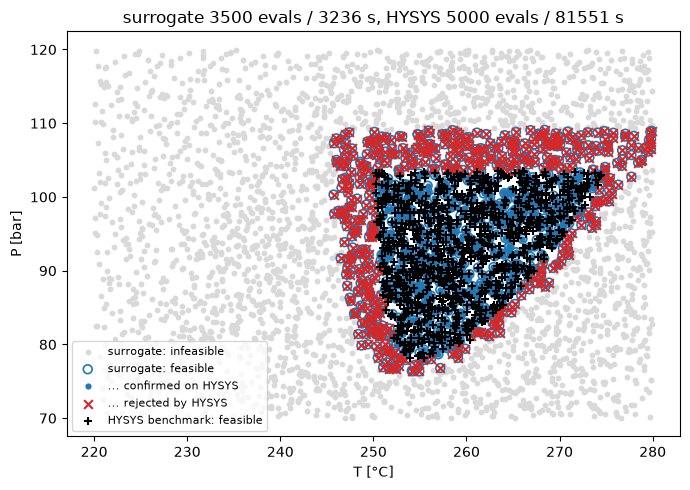

In [56]:
# Surrogate feasibility against the independent HYSYS benchmark
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sur_df.temperature_C[~sur_df.feasible], sur_df.pressure_bar[~sur_df.feasible],
           s=10, color="0.85", label="surrogate: infeasible")
ax.scatter(cand.temperature_C, cand.pressure_bar, s=40, facecolors="none", edgecolors="C0", lw=1.2,
           label="surrogate: feasible")
ax.scatter(cand.temperature_C[cand.verified], cand.pressure_bar[cand.verified], s=12, color="C0",
           label="... confirmed on HYSYS")
ax.scatter(cand.temperature_C[~cand.verified], cand.pressure_bar[~cand.verified], s=40, marker="x", color="C3",
           label="... rejected by HYSYS")
ax.scatter(hys_df.temperature_C[hys_df.feasible], hys_df.pressure_bar[hys_df.feasible], s=40, marker="+", color="k",
           label="HYSYS benchmark: feasible")
ax.set(xlabel="T [°C]", ylabel="P [bar]",
       title=f"surrogate {len(sur_df)} evals / {runs['surrogate']['wall_s']:.0f} s, "
             f"HYSYS {len(hys_df)} evals / {runs['hysys']['wall_s']:.0f} s")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()

In [58]:
import pickle
KEEP = ["df_sweep", "df_dom", "pfr_box", "df_pfr", "runs", "cand"]
with open(f"backup{TAG}.pkl", "wb") as f:
    pickle.dump({k: globals()[k] for k in KEEP if k in globals()}, f)

In [69]:
print(f"True-Feasible-Rate (with 5% constraint relaxation): {100 * (cand.verified.sum() / len(cand)):.2f} %")

True-Feasible-Rate (with 5% constraint relaxation): 52.91 %
